In [1]:
import anndata as ad 
import sys 
import pandas as pd
import scanpy as sc
sys.path.append('../../task_grn_inference')
from src.utils.util import sum_by  
def plot_embedding(adata, covariates=['Cluster_names', 'Sex']):

    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    sc.pp.pca(adata, use_highly_variable=True)
    sc.pp.neighbors(adata, n_neighbors=10)
    sc.tl.umap(adata)

    # Plot UMAP & PCA
    sc.pl.umap(adata, color=covariates, wspace=0.3)
    sc.pl.pca(adata, color=covariates, wspace=0.3)


In [ ]:
def format_pbmc_ageing():
    '''
    Takes the pbmc_ageing data and obs data and formats it to be used in the pipeline (this replaces data7_allTPs)
    '''
    # - read the data 
    adata_pbmc = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/raw_counts_h5ad/pbmc_gex_raw_with_var_obs.h5ad')
    obs_pbmc = pd.read_csv('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/all_pbmcs/all_pbmcs_metadata.csv', index_col=0)
    adata_pbmc.obs = adata_pbmc.obs[[]].merge(obs_pbmc, left_index=True, right_index=True)

    # - basic filtering
    sc.pp.filter_genes(adata_pbmc, min_cells=100)
    sc.pp.filter_cells(adata_pbmc, min_genes=200)

    # - formatize the cols
    adata_pbmc.obs['orig.ident'] = 'data7_allTPs_jalil'
    adata_pbmc.obs.rename(columns={'Donor_id':'donor_id', 'Age':'age', 'Sex':'sex', 'Batch':'batch_info', 'Cluster_names': 'ct_major_published'}, inplace=True)
    adata_pbmc.obs = adata_pbmc.obs[['orig.ident', 'donor_id', 'age', 'sex', 'batch_info', 'ct_major_published']]

    # - cleanup
    del adata_pbmc.uns 
    adata_pbmc.var.drop(columns=['n_cells'], inplace=True)

    # -save
    adata_pbmc.write('/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/data7_allTPs_jalil_CMtx.h5ad')


## data7 original

### All time points

In [14]:
if True:

    adata_pbmc.obs['unique_sample'] = adata_pbmc.obs['age'].astype(str) + '_' + adata_pbmc.obs['donor_id'].astype(str) + '_'+ adata_pbmc.obs['ct_major_published'].astype(str)  

    adata_pbmc.obs['unique_sample'] = adata_pbmc.obs['unique_sample'].astype('category')

    adata_pbmc_bulk = sum_by(adata_pbmc, col='unique_sample')
    sc.pp.normalize_total(adata_pbmc_bulk)
    sc.pp.log1p(adata_pbmc_bulk)
    adata_pbmc_bulk.write('../output/pbmc_bulk.h5ad')
else:
    adata_pbmc_bulk = ad.read('../output/pbmc_bulk.h5ad')
    

/vol/tmp/users/jnourisa/ipykernel_735201/3360864089.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_pbmc.obs['unique_sample'] = adata_pbmc.obs['age'].astype(str) + '_' + adata_pbmc.obs['donor_id'].astype(str) + '_'+ adata_pbmc.obs['ct_major_published'].astype(str)
/vol/tmp/users/jnourisa/ipykernel_735201/3360864089.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_pbmc.obs['unique_sample'] = adata_pbmc.obs['unique_sample'].astype('category')


/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:385: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


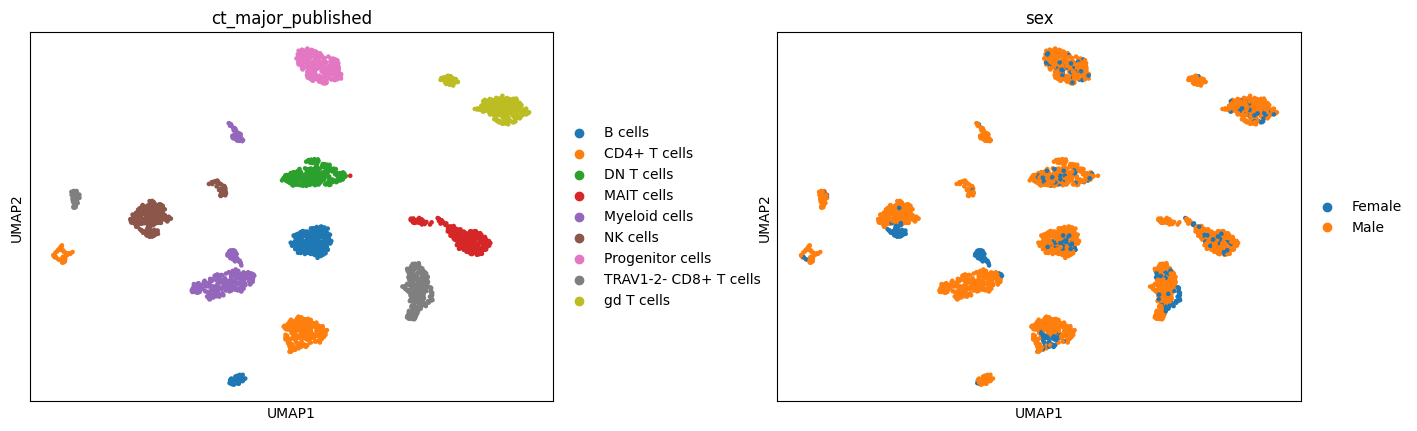

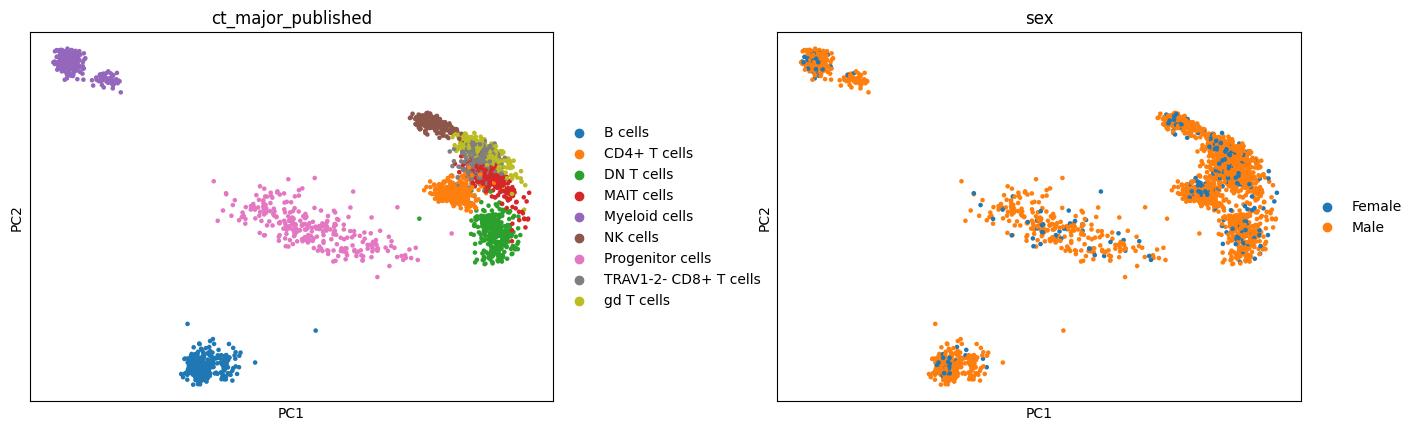

In [17]:
plot_embedding(adata_pbmc_bulk, covariates=['ct_major_published', 'sex'])

### First time point

In [15]:
obs_subset = adata_pbmc_bulk.obs.sort_values("Age").drop_duplicates(subset=["Donor_id", "Cluster_names"], keep="first")
adata_pbmc_bulk_subset = adata_pbmc_bulk[obs_subset.index]
adata_pbmc_bulk_subset

View of AnnData object with n_obs × n_vars = 1485 × 29493
    obs: 'unique_sample', 'orig.ident', 'Donor_id', 'Sex', 'Cluster_numbers', 'Age', 'Age_group', 'Cluster_names'
    var: 'n_cells'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'Cluster_names_colors', 'Sex_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:385: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


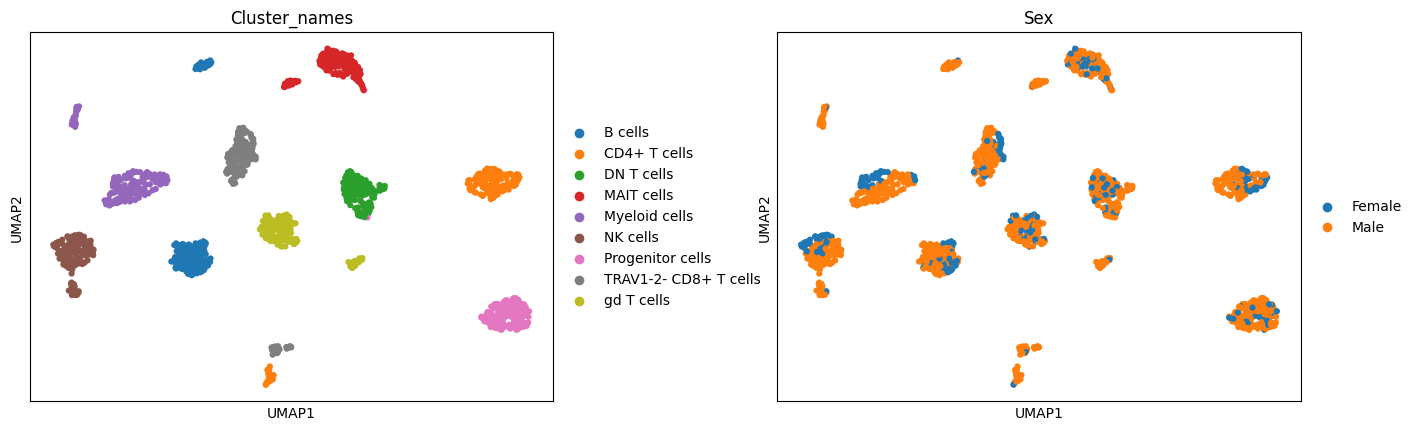

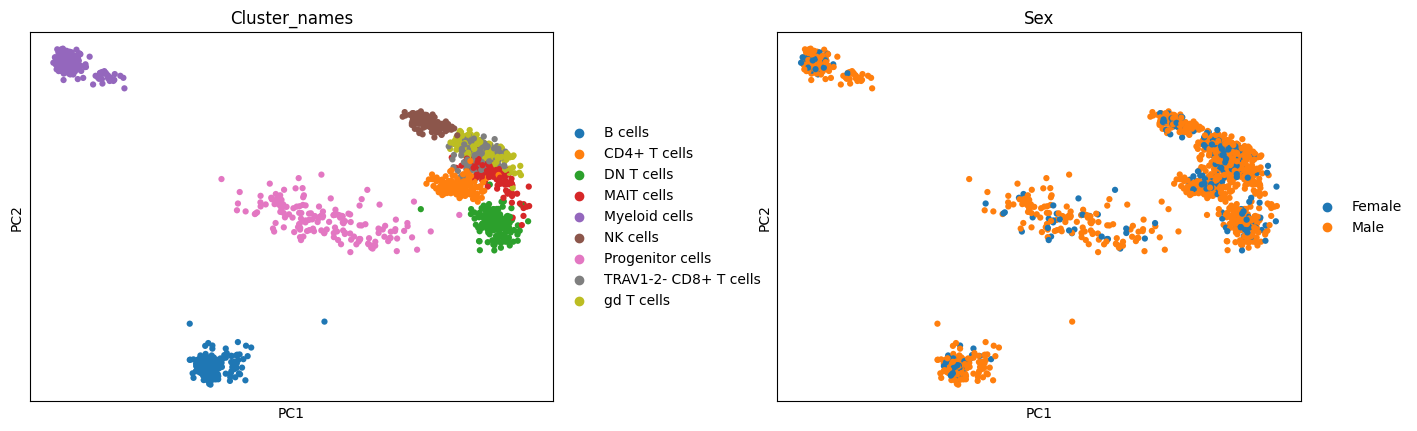

In [ ]:
plot_embedding(adata_pbmc_bulk_subset)

## data7 ali

### All time points

In [6]:
adata7 = ad.read_h5ad("/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/data7_allTPs_CMtx.h5ad")
adata7.obs['unique_sample'] = adata7.obs['age'].astype(str) + '_' + adata7.obs['donor_id'].astype(str) + '_'+ adata7.obs['ct_major_published'].astype(str)  
adata7.obs['unique_sample'] = adata7.obs['unique_sample'].astype('category')
print(adata7.obs['unique_sample'].nunique()) 

sc.pp.filter_genes(adata7, min_cells=10)
sc.pp.filter_cells(adata7, min_genes=200)


2811


In [ ]:

adata7_bulk = sum_by(adata7, col='unique_sample')
sc.pp.normalize_total(adata7_bulk)
sc.pp.log1p(adata7_bulk)
adata7_bulk.write('../output/pbmc_bulk.h5ad')

In [2]:
adata7_bulk = ad.read('../output/pbmc_bulk.h5ad')
adata7_bulk

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


AnnData object with n_obs × n_vars = 2811 × 29493
    obs: 'unique_sample', 'orig.ident', 'ct_major_published', 'batch_info', 'sex', 'age', 'donor_id'
    var: 'n_cells'
    uns: 'log1p'

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:385: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


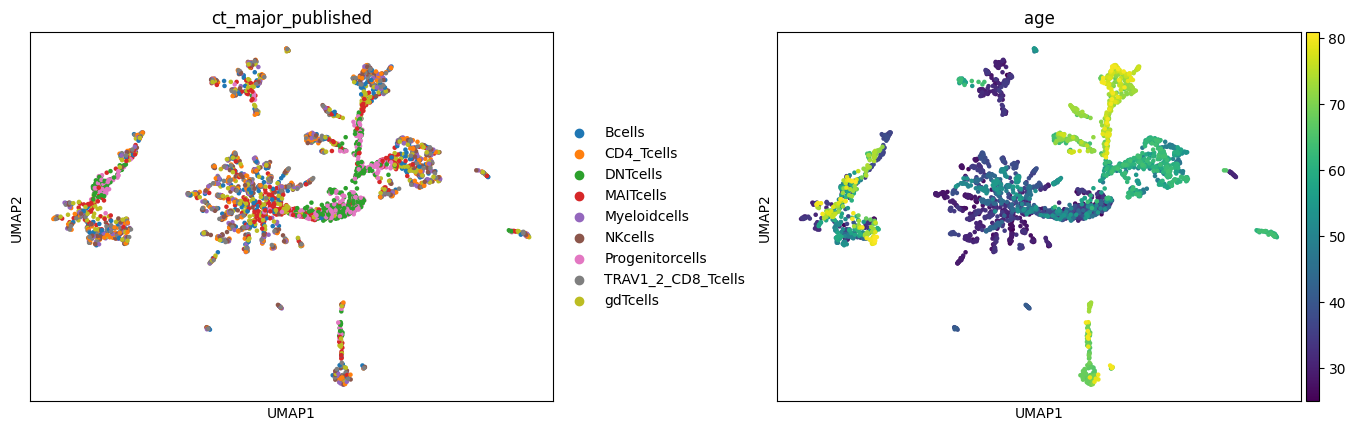

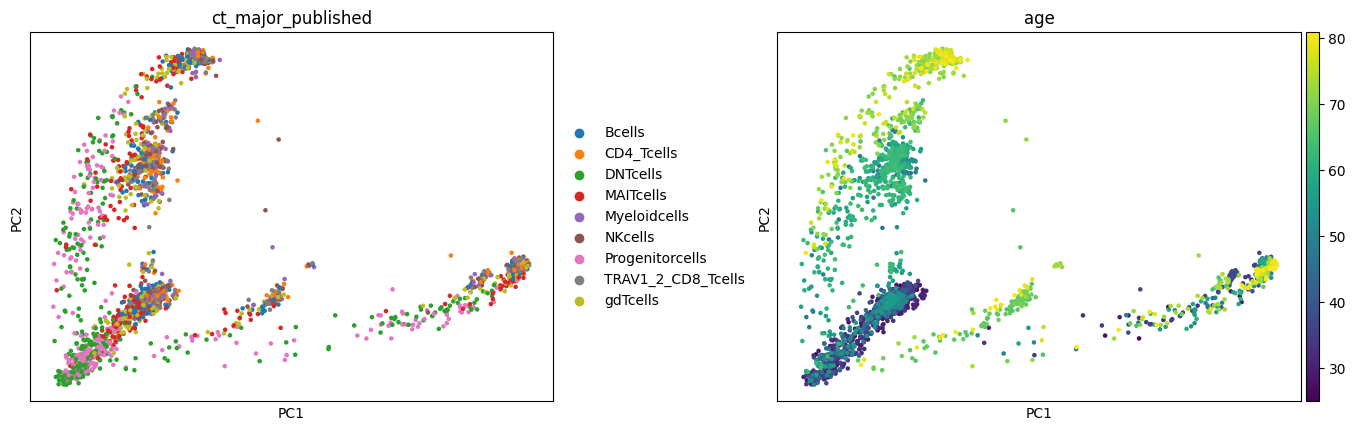

In [3]:
plot_embedding(adata7_bulk, covariates=['ct_major_published', 'age'])

### First time points

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:693: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:385: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


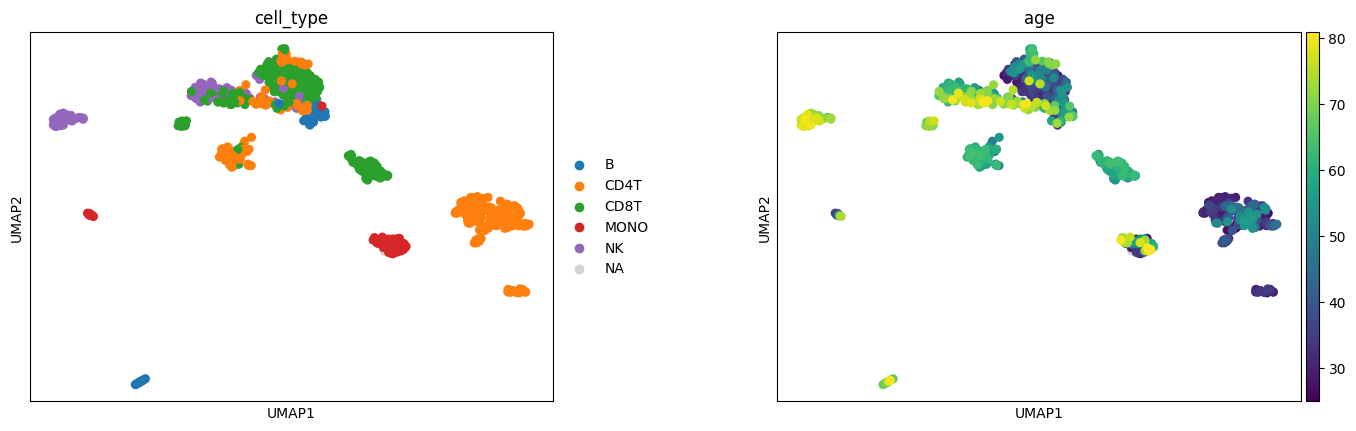

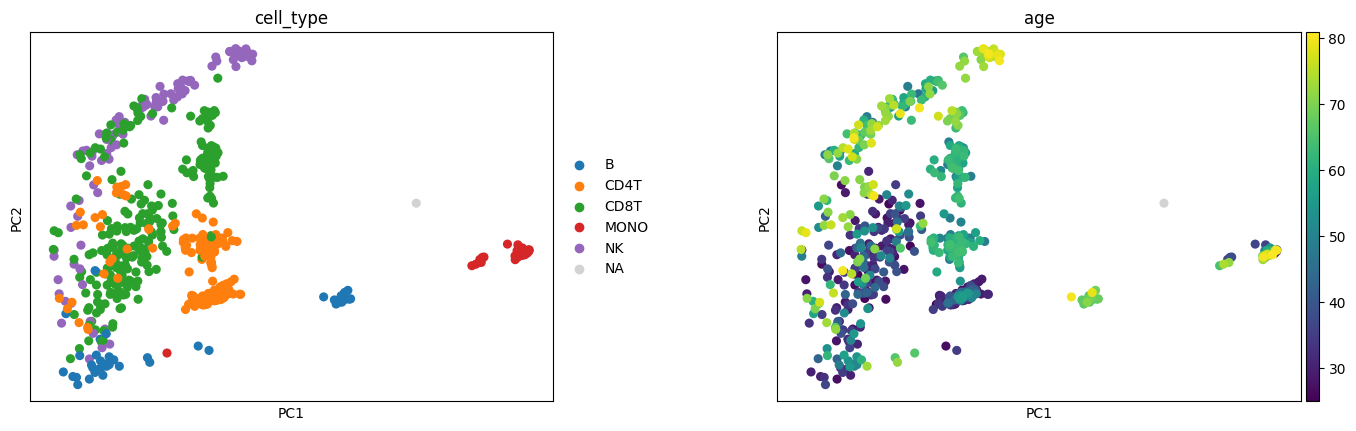

In [13]:
obs_subset = adata7_bulk.obs.sort_values("age").drop_duplicates(subset=["donor_id", "cell_type"], keep="first")
adata7_bulk_subset = adata7_bulk[obs_subset.index]
plot_embedding(adata7_bulk_subset, covariates=['cell_type', 'age'])